Python Assignment....

In [16]:
import pandas as pd
import yfinance as yf

# Download 6 months of Microsoft stock data
data = yf.download("MSFT", period="6mo")

# Show only 'Close' column (last 5 rows)
print("\nTail of Microsoft (MSFT) stock data (Close prices only):\n")
print(data[["Close"]].tail())


C:\Users\Jeshrun\AppData\Local\Temp\ipykernel_21300\2280785922.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("MSFT", period="6mo")
[*********************100%***********************]  1 of 1 completed


Tail of Microsoft (MSFT) stock data (Close prices only):

Price            Close
Ticker            MSFT
Date                  
2025-09-19  517.929993
2025-09-22  514.450012
2025-09-23  509.230011
2025-09-24  510.149994
2025-09-25  507.029999


C:\Users\Jeshrun\AppData\Local\Temp\ipykernel_21300\1530240169.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="6mo")
[*********************100%***********************]  1 of 1 completed



Daily Returns for META (5 current entries):
2025-09-19 → Return: -0.0024 → Percentage Return: -0.24%  
2025-09-22 → Return: -0.0163 → Percentage Return: -1.63%  
2025-09-23 → Return: -0.0128 → Percentage Return: -1.28%  
2025-09-24 → Return: 0.0070 → Percentage Return: 0.70%  
2025-09-25 → Return: -0.0154 → Percentage Return: -1.54%  




Average Volatility of META: 0.0268


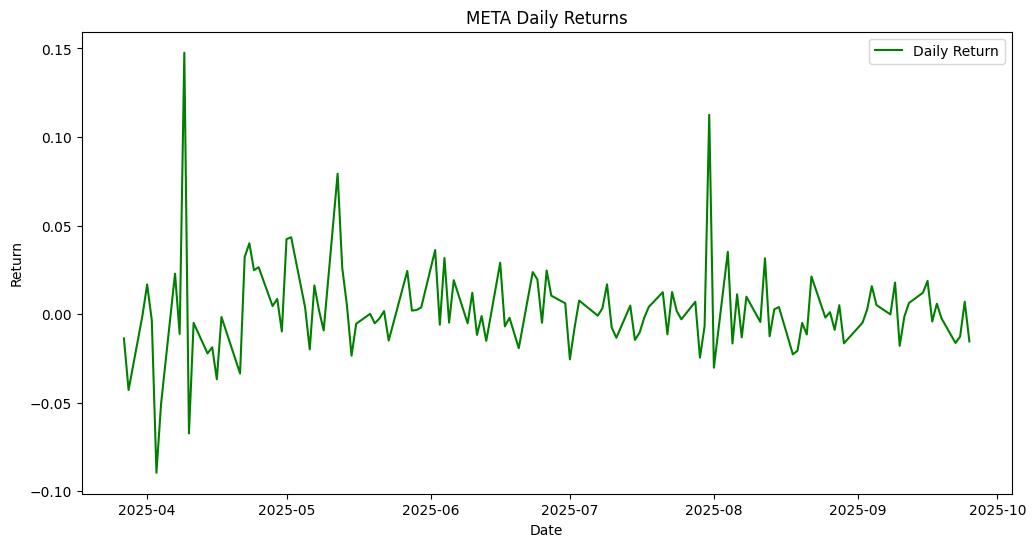

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import yfinance as yf

def analyze_stock(ticker):
    # Get last 6 months of daily stock data
    data = yf.download(ticker, period="6mo")

    if not data.empty:
        # Calculate daily % returns
        data["Daily Return"] = data["Close"] / data["Close"].shift(1) - 1 #OR data["Close"].pct_change()
        data["Daily Percentage Return"] = (data['Close'] / data['Close'].shift(1)-1) *100

        print(f"\nDaily Returns for {ticker} (5 current entries):")
        for (date, ret) , (_, pct_ret) in zip(data["Daily Return"].tail().items(),data["Daily Percentage Return"].tail().items()):
           print(f"{date.date()} → Return: {ret:.4f} → Percentage Return: {pct_ret:.2f}%  ")
           
        print("\n\n")


        # Drop the first NaN value
        data = data.dropna()

        # Calculate average volatility
        avg_volatility = data["Daily Return"].std()

        print(f"\nAverage Volatility of {ticker}: {avg_volatility:.4f}")
        return data
    else:
        print(f"No data found for {ticker}. Please change the ticker symbol.")
        return None

# Take input from user
ticker_symbol = input('''Enter the stock ticker symbol.... 
ex-
Microsoft Corporation (MSFT)
Amazon.com, Inc. (AMZN)
Meta (formerly Facebook) Inc. (META)
Tesla Motors (TSLA)
 : ''')

data = analyze_stock(ticker_symbol)

if data is not None:
    plt.figure(figsize=(12,6))
    plt.plot(data['Daily Return'], label='Daily Return', color='green')
    plt.title(f'{ticker_symbol} Daily Returns')
    plt.xlabel('Date')
    plt.ylabel('Return')
    plt.legend()
    plt.show()